# Flujo de Trabajo de Imputación de Contaminación para Pampaneira y Bubión

Este cuaderno ejecuta el pipeline refactorizado para imputar valores faltantes en el conjunto de datos de Pampaneira.

## 1. Configuración e Importaciones

Aseguramos que la raíz del proyecto esté en el path de Python. Ajusta la profundidad del path ('../') según sea necesario dependiendo de dónde se encuentre este cuaderno en relación con la raíz del proyecto.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import os
import sys
from sklearn.preprocessing import StandardScaler # Mantener para uso directo/verificación potencial
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.nn import SmoothL1Loss

# Asegurar que la raíz del proyecto esté en el Python path
# Ajusta la profundidad del path ('../') según sea necesario
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

Importamos los módulos refactorizados del proyecto:

In [2]:
# Importar módulos refactorizados
from pampaneira_imputation import config
from pampaneira_imputation import data_loader as dl
from pampaneira_imputation import data_preprocessor as dp
from pampaneira_imputation import imputation_methods as im
from pampaneira_imputation import evaluation as ev
from pampaneira_imputation import utils


████████╗██╗███╗   ███╗███████╗    ███████╗███████╗██████╗ ██╗███████╗███████╗    █████╗ ██╗
╚══██╔══╝██║████╗ ████║██╔════╝    ██╔════╝██╔════╝██╔══██╗██║██╔════╝██╔════╝   ██╔══██╗██║
   ██║   ██║██╔████╔██║█████╗█████╗███████╗█████╗  ██████╔╝██║█████╗  ███████╗   ███████║██║
   ██║   ██║██║╚██╔╝██║██╔══╝╚════╝╚════██║██╔══╝  ██╔══██╗██║██╔══╝  ╚════██║   ██╔══██║██║
   ██║   ██║██║ ╚═╝ ██║███████╗    ███████║███████╗██║  ██║██║███████╗███████║██╗██║  ██║██║
   ╚═╝   ╚═╝╚═╝     ╚═╝╚══════╝    ╚══════╝╚══════╝╚═╝  ╚═╝╚═╝╚══════╝╚══════╝╚═╝╚═╝  ╚═╝╚═╝
ai4ts v0.0.3 - building AI for unified time-series analysis, https://time-series.ai 



Importamos SAITS por separado (asumiendo que pypots está instalado):

In [3]:
# Importar SAITS por separado (asumiendo que pypots está instalado)
try:
    from pypots.imputation import SAITS, Transformer
except ImportError:
    print("Advertencia: No se encontró la librería pypots. La imputación con SAITS no estará disponible.")
    SAITS = None # Definir como None si no está disponible

Configuramos pandas y la visualización:

In [4]:
# Configurar pandas y visualización
pd.options.mode.chained_assignment = None
pd.reset_option('display.max_rows')
pd.reset_option('display.max_columns')
plt.rcParams["figure.figsize"] = [12, 4]
warnings.filterwarnings("ignore") # Usar con precaución

## 2. Carga de Datos

Cargamos los datos de la intersección (filtrados para PAM_2):

In [5]:
# Cargar datos de intersección (filtrados para PAM_2)
try:
    df_int_raw = dl.load_intersection_data(
        filepath=config.INTERSECTION_FILE,
        target_truck_pos=config.TARGET_TRUCK_POS
    )
    print(f"Forma de los datos de intersección cargados: {df_int_raw.shape}")
    print(f"Rango de fechas: {df_int_raw[config.DATE_COL].min()} a {df_int_raw[config.DATE_COL].max()}")
    # display(df_int_raw.head()) # Opcional: mostrar encabezado
except Exception as e:
    print(f"Error al cargar los datos de intersección: {e}")
    # Detener ejecución o manejar el error apropiadamente
    raise

Forma de los datos de intersección cargados: (1335, 115)
Rango de fechas: 2023-01-17 17:00:00+00:00 a 2023-06-27 00:00:00+00:00


## 3. Preprocesamiento de Datos

### 3.1 Rellenar Marcas de Tiempo Faltantes (Dentro de Periodos Definidos)

Creamos el rango de fechas completo que cubre ambos periodos conocidos de datos del camión:

In [6]:
df_int_reindexed = dp.fill_missing_timestamps(df_int_raw, config.PERIOD_1_START, config.PERIOD_2_END)
print(f"Forma después de reindexar a periodos combinados: {df_int_reindexed.shape}")

Forma después de reindexar a periodos combinados: (3840, 114)


Verificamos los NaNs introducidos por la reindexación:

In [7]:
# Verificar los NaNs introducidos
print(f"NaNs introducidos por reindexación: {df_int_reindexed.isnull().sum().sum()}")

NaNs introducidos por reindexación: 288216


In [8]:
df_int_reindexed

,vehicles_PAM_1_OUT,vehicles_PAM_1_OUT_Zona_Granada,vehicles_PAM_1_OUT_Zona_Catalunia_y_Otras,vehicles_PAM_1_OUT_Zona_Andalucia_no_GR,vehicles_PAM_1_OUT_Extranjero,vehicles_PAM_1_OUT_Zona_Comunidad_de_Madrid,vehicles_PAM_1_OUT_Zona_Extremadura_y_Otras,vehicles_PAM_1_OUT_Zona_Otras,vehicles_PAM_1_OUT_5_seats,vehicles_PAM_1_OUT_+5_seats,...,NO,O3,PM10,eBC_ff,eBC_bb,TEMP,RH,WS,WD,PRES
2023-01-18 00:00:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.1,NaN,0.0,NaN,NaN,6.6,52.9,3.89,114.50,878.0
2023-01-18 01:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-01-18 02:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-01-18 03:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-01-18 04:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-06-26 19:00:00+00:00,7.0,5.0,1.0,0.0,1.0,0.0,0.0,0.0,5.0,0.0,...,1.5,111.4,7.8,0.6,0.1,31.4,21.5,1.12,246.34,893.3
2023-06-26 20:00:00+00:00,3.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,...,0.4,99.6,23.0,0.3,0.1,28.8,26.0,0.81,7.46,893.6
2023-06-26 21:00:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.1,78.8,11.3,0.4,0.1,25.7,29.5,1.06,129.23,893.9
2023-06-26 22:00:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.1,77.4,1.9,0.2,0.1,24.7,27.9,1.25,133.45,894.3


### 3.2 Dividir en Periodos

Establecemos la columna de fecha como índice y dividimos el DataFrame en los dos periodos definidos en la configuración.

In [9]:
# Dividir en Periodos
periodo_1_raw, periodo_2_raw = dp.split_by_period(df_int_reindexed)

print(f"Forma del Periodo 1: {periodo_1_raw.shape}")
print(f"Forma del Periodo 2: {periodo_2_raw.shape}")

Forma del Periodo 1: (1332, 114)
Forma del Periodo 2: (480, 114)


### 3.4 Dividir, Escalar, Ventanear y Crear Ausencia para el Periodo 1

Esta función ahora maneja la división train/val/test, el escalado (normalización Z-score), la creación de ventanas deslizantes (`sliding window`) y la introducción artificial de valores faltantes (`missingness`) según la configuración.

Para dividir el periodo del 18 de enero de 2023 al 14 de marzo de 2023 en entrenamiento, validación y prueba siguiendo un esquema análogo al del Beijing Multi-Site Air-Quality Dataset, vamos a asignar los datos de manera similar a cómo se hizo en ese conjunto.

El esquema original divide los datos en tres partes:

- **Fase de entrenamiento (80% del dataset):** Primeros 45 días
   - **Training:** 80% de los 45 días: 36 días
   - **Validación** 20% restante de los 45 días: 9 días.
- **Prueba (20% del dataset):** 20% del dataset:  11 días.

El periodo de tiempo es del 18 de enero de 2023 al 14 de marzo de 2023. **hay 56 días.**

- **Conjunto de entrenamiento: 18 de enero de 2023 - 21 de febrero de 2023 (36 días)**
- **Conjunto de validación: 22 de febrero de 2023 - 2 de marzo de 2023 (9 días)**.
- **Conjunto de prueba: 3 de marzo de 2023 - 14 de marzo de 2023) (12 días)**



In [10]:
# Dividir, Escalar, Ventanear y Crear Ausencia para el Periodo 1
# Esta función ahora maneja la división train/val/test, escalado, ventaneo y creación de valores faltantes
try:
    processed_data = dp.preprocess_for_imputation(
        periodo_1_raw,
        feature_cols=config.FEATURE_COLUMNS,
        n_steps=config.N_STEPS,
        missing_rate=config.MISSING_RATE,
        missing_pattern=config.MISSING_PATTERN
        # Añadir otros argumentos de missingness si es necesario, ej., min_missing_len=...
    )
    print("Preprocesamiento completo. Estructura de datos:")
    for key, value in processed_data.items():
        if isinstance(value, np.ndarray):
            print(f"- {key}: forma {value.shape}")
        elif isinstance(value, pd.DataFrame):
            print(f"- {key}: forma {value.shape}")
        elif isinstance(value, pd.Index):
             print(f"- {key}: longitud {len(value)}")
        elif not isinstance(value, StandardScaler): # No imprimir detalles del scaler
            print(f"- {key}: {value}")

except ValueError as e:
    print(f"Error durante el preprocesamiento: {e}")
    raise

Introduciendo 10.0% de datos faltantes con patrón 'point' (seed=42)...
Preprocesamiento completo. Estructura de datos:
- n_steps: 24
- n_features: 114
- train_X_ori: forma (841, 24, 114)
- val_X_ori: forma (217, 24, 114)
- test_X_ori: forma (253, 24, 114)
- train_X: forma (841, 24, 114)
- val_X: forma (217, 24, 114)
- test_X: forma (253, 24, 114)
- train_preexisting_nan_mask: forma (841, 24, 114)
- val_preexisting_nan_mask: forma (217, 24, 114)
- test_preexisting_nan_mask: forma (253, 24, 114)
- train_indicating_mask: forma (841, 24, 114)
- val_indicating_mask: forma (217, 24, 114)
- test_indicating_mask: forma (253, 24, 114)
- train_artificial_mask: forma (841, 24, 114)
- val_artificial_mask: forma (217, 24, 114)
- test_artificial_mask: forma (253, 24, 114)
- n_train_samples: 841
- n_val_samples: 217
- n_test_samples: 253


Preparamos los conjuntos de datos para PyPOTS (u otras bibliotecas) si es necesario:

In [11]:
# Preparar datasets para PyPOTS (u otras bibliotecas) si es necesario
dataset_for_training = {"X": processed_data['train_X']}
dataset_for_validating = {"X": processed_data['val_X'], "X_ori": processed_data['val_X_ori']}
# Nota: La validación en PyPOTS usualmente necesita X_ori para calcular la pérdida sobre los valores originales
# antes del enmascaramiento, pero nuestra evaluación calcula métricas en el conjunto de test usando test_X_ori

dataset_for_testing = {
    "X": processed_data['test_X'], # Datos con NaNs para la entrada del modelo de imputación
    "X_ori": processed_data['test_X_ori'], # Datos originales (escalados) antes de enmascarar
    "indicating_mask": processed_data['test_indicating_mask'] # Máscara de los NaNs introducidos
}

### 3.4 Dividir, Escalar, Ventanear y Crear Ausencia para el Periodo 2

Esta función ahora maneja la división train/val/test, el escalado (normalización Z-score), la creación de ventanas deslizantes (`sliding window`) y la introducción artificial de valores faltantes (`missingness`) según la configuración.

In [12]:
periodo_2_raw

,vehicles_PAM_1_OUT,vehicles_PAM_1_OUT_Zona_Granada,vehicles_PAM_1_OUT_Zona_Catalunia_y_Otras,vehicles_PAM_1_OUT_Zona_Andalucia_no_GR,vehicles_PAM_1_OUT_Extranjero,vehicles_PAM_1_OUT_Zona_Comunidad_de_Madrid,vehicles_PAM_1_OUT_Zona_Extremadura_y_Otras,vehicles_PAM_1_OUT_Zona_Otras,vehicles_PAM_1_OUT_5_seats,vehicles_PAM_1_OUT_+5_seats,...,NO,O3,PM10,eBC_ff,eBC_bb,TEMP,RH,WS,WD,PRES
2023-06-07 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-06-07 01:00:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.1,88.3,NaN,0.1,0.1,16.7,68.5,2.08,116.29,887.5
2023-06-07 02:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-06-07 03:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-06-07 04:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-06-26 19:00:00+00:00,7.0,5.0,1.0,0.0,1.0,0.0,0.0,0.0,5.0,0.0,...,1.5,111.4,7.8,0.6,0.1,31.4,21.5,1.12,246.34,893.3
2023-06-26 20:00:00+00:00,3.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,...,0.4,99.6,23.0,0.3,0.1,28.8,26.0,0.81,7.46,893.6
2023-06-26 21:00:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.1,78.8,11.3,0.4,0.1,25.7,29.5,1.06,129.23,893.9
2023-06-26 22:00:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.1,77.4,1.9,0.2,0.1,24.7,27.9,1.25,133.45,894.3


### Fechas de división del periodo 2 (20 días)

- 80% del dataset Fase de entrenamiento: 16 días
    - **Training:** 80% de 16: **13 días** (2023-06-07 al 2023-06-19)
    - **Validación:** 20% de 16: **3 días** (2023-06-20 al 2023-06-22)
- 20% del dataset **Testing**: **4 días** (2023-06-23 al 2023-06-26)

In [13]:
# Dividir, Escalar, Ventanear y Crear Ausencia para el Periodo 1
# Esta función ahora maneja la división train/val/test, escalado, ventaneo y creación de valores faltantes
try:
    processed_data2 = dp.preprocess_for_imputation(
        periodo_2_raw,
        feature_cols=config.FEATURE_COLUMNS,
        n_steps=config.N_STEPS,
        missing_rate=config.MISSING_RATE,
        missing_pattern=config.MISSING_PATTERN,
        train_starn=config.TRAIN_2_START_DATE,
        train_end=config.TRAIN_2_END_DATE,
        val_start=config.VAL_2_START_DATE,
        val_end=config.VAL_2_END_DATE,
        test_start=config.TEST_2_START_DATE,
        test_end=config.TEST_2_END_DATE,
        # Añadir otros argumentos de missingness si es necesario, ej., min_missing_len=...
    )
    print("Preprocesamiento completo. Estructura de datos:")
    for key, value in processed_data.items():
        if isinstance(value, np.ndarray):
            print(f"- {key}: forma {value.shape}")
        elif isinstance(value, pd.DataFrame):
            print(f"- {key}: forma {value.shape}")
        elif isinstance(value, pd.Index):
             print(f"- {key}: longitud {len(value)}")
        elif not isinstance(value, StandardScaler): # No imprimir detalles del scaler
            print(f"- {key}: {value}")

except ValueError as e:
    print(f"Error durante el preprocesamiento: {e}")
    raise

Introduciendo 10.0% de datos faltantes con patrón 'point' (seed=42)...
Preprocesamiento completo. Estructura de datos:
- n_steps: 24
- n_features: 114
- train_X_ori: forma (841, 24, 114)
- val_X_ori: forma (217, 24, 114)
- test_X_ori: forma (253, 24, 114)
- train_X: forma (841, 24, 114)
- val_X: forma (217, 24, 114)
- test_X: forma (253, 24, 114)
- train_preexisting_nan_mask: forma (841, 24, 114)
- val_preexisting_nan_mask: forma (217, 24, 114)
- test_preexisting_nan_mask: forma (253, 24, 114)
- train_indicating_mask: forma (841, 24, 114)
- val_indicating_mask: forma (217, 24, 114)
- test_indicating_mask: forma (253, 24, 114)
- train_artificial_mask: forma (841, 24, 114)
- val_artificial_mask: forma (217, 24, 114)
- test_artificial_mask: forma (253, 24, 114)
- n_train_samples: 841
- n_val_samples: 217
- n_test_samples: 253


In [14]:
# Preparar datasets para PyPOTS (u otras bibliotecas) si es necesario
dataset_for_training2 = {"X": processed_data2['train_X']}
dataset_for_validating2 = {"X": processed_data2['val_X'], "X_ori": processed_data2['val_X_ori']}
# Nota: La validación en PyPOTS usualmente necesita X_ori para calcular la pérdida sobre los valores originales
# antes del enmascaramiento, pero nuestra evaluación calcula métricas en el conjunto de test usando test_X_ori

dataset_for_testing2 = {
    "X": processed_data2['test_X'], # Datos con NaNs para la entrada del modelo de imputación
    "X_ori": processed_data2['test_X_ori'], # Datos originales (escalados) antes de enmascarar
    "indicating_mask": processed_data2['test_indicating_mask'] # Máscara de los NaNs introducidos
}

## 4. Métodos de Imputación para Periodo 1

Aplicamos métodos base a los datos del conjunto de test (`dataset_for_testing['X']`). Almacenamos los resultados en un diccionario.

In [15]:
# Aplicar métodos base a los datos del conjunto de test (`dataset_for_testing['X']`)
X_test_missing = dataset_for_testing['X']
imputed_results = {} # Diccionario para almacenar resultados

print("\nEjecutando métodos de imputación base...")


Ejecutando métodos de imputación base...


### 4.1. Modelos Baseline

####
4.1 Imputación por Mediana

Rellenamos los valores faltantes utilizando la mediana de cada característica (columna) calculada sobre todo el conjunto de datos de test (a través de todas las muestras y pasos de tiempo).

In [16]:
imputed_results['median'] = im.impute_median_sample_wise(X_test_missing)
print(f"Forma imputación mediana: {imputed_results['median'].shape}, NaNs: {np.isnan(imputed_results['median']).sum()}")

  Midiendo tiempo para 'impute_median_sample_wise'...
  Finalizado 'impute_median_sample_wise' en 5.442008 segundos
Forma imputación mediana: (253, 24, 114), NaNs: 0


#### 4.2 Imputación por Media

Similar a la mediana, pero usamos la media de cada característica para rellenar los valores faltantes.

In [17]:
imputed_results['mean'] = im.impute_mean_sample_wise(X_test_missing)

print(f"Forma imputación media: {imputed_results['mean'].shape}, NaNs: {np.isnan(imputed_results['mean']).sum()}")

  Midiendo tiempo para 'impute_mean_sample_wise'...
  Finalizado 'impute_mean_sample_wise' en 1.974218 segundos
Forma imputación media: (253, 24, 114), NaNs: 0


#### 4.3 Interpolación Lineal

Rellenamos los valores faltantes mediante interpolación lineal a lo largo del eje temporal (pasos de tiempo) para cada muestra y característica de forma independiente.

In [18]:

imputed_results['linear'] = im.impute_linear(X_test_missing)
print(f"Forma imputación lineal: {imputed_results['linear'].shape}, NaNs: {np.isnan(imputed_results['linear']).sum()}")

  Midiendo tiempo para 'impute_linear'...
  Finalizado 'impute_linear' en 0.812822 segundos
Forma imputación lineal: (253, 24, 114), NaNs: 0


#### 4.4 Relleno Forward/Backward (ffill/bfill)

Nota: Estos métodos pueden requerir eliminar columnas como `WS`, `WD` si causan problemas o no son necesarias. La función de imputación en sí no elimina columnas, pero la evaluación podría necesitar alineación. Asumiremos por ahora que imputamos todas las características. La evaluación maneja la posible eliminación de columnas. Alternativamente, modificamos los datos de entrada antes de pasarlos a la imputación:

In [19]:
# ### 4.4 Relleno Forward/Backward (ffill/bfill)
# Nota: Estos métodos pueden requerir eliminar columnas como WS, WD si causan problemas.
# Modificamos los datos de entrada si es necesario:
X_test_missing_no_ws_wd = X_test_missing.copy()
cols_to_drop_indices = [config.FEATURE_COLUMNS.index(col) for col in config.COLS_TO_DROP_FOR_BASELINE if col in config.FEATURE_COLUMNS]

if cols_to_drop_indices:
    print(f"Eliminando columnas en índices {cols_to_drop_indices} para métodos Fill.")
    X_test_missing_no_ws_wd = np.delete(X_test_missing, cols_to_drop_indices, axis=2)
else:
    X_test_missing_no_ws_wd = X_test_missing # No hay columnas que eliminar

imputed_results['ffill'] = im.impute_forward(X_test_missing_no_ws_wd)
imputed_results['bfill'] = im.impute_backward(X_test_missing_no_ws_wd)
print(f"Forma imputación Forward fill {imputed_results['ffill'].shape}, NaNs: {np.isnan(imputed_results['ffill']).sum()}")
print(f"Forma imputación Backward fill: {imputed_results['bfill'].shape}, NaNs: {np.isnan(imputed_results['bfill']).sum()}")

Eliminando columnas en índices [111, 112] para métodos Fill.
  Midiendo tiempo para 'impute_forward'...
  Finalizado 'impute_forward' en 0.064846 segundos
  Midiendo tiempo para 'impute_backward'...
  Finalizado 'impute_backward' en 0.063610 segundos
Forma imputación Forward fill (253, 24, 112), NaNs: 0
Forma imputación Backward fill: (253, 24, 112), NaNs: 0


### 4.5. Modelo Transformer

In [20]:
transformer_model = im.fit_transformer(dataset_for_training, dataset_for_validating)
imputed_results['transformer'] = im.impute_transformer(transformer_model,
                                                       dataset_for_testing)

2025-04-29 19:56:41 [INFO]: No given device, using default device: cpu
2025-04-29 19:56:41 [INFO]: Model files will be saved to ../results/imputation/transformer/20250429_T195641
2025-04-29 19:56:41 [INFO]: Tensorboard file will be saved to ../results/imputation/transformer/20250429_T195641/tensorboard
2025-04-29 19:56:41 [INFO]: Using customized MAE as the training loss function.
2025-04-29 19:56:41 [INFO]: Using customized MSE as the validation metric function.
2025-04-29 19:56:41 [INFO]: Transformer initialized with the given hyperparameters, the number of trainable parameters: 439,922


  Midiendo tiempo para 'fit_transformer'...

---> Ejecutando lógica de imputación con Transformer...
    Inicializando Transformer model...
    Configurando optimizer, scheduler, loss...
    Training Transformer model...


2025-04-29 19:56:42 [INFO]: Epoch 001 - training loss (MAE): 1.2300, validation MSE: 1.0431
2025-04-29 19:56:43 [INFO]: Epoch 002 - training loss (MAE): 0.9207, validation MSE: 0.9687
2025-04-29 19:56:44 [INFO]: Epoch 003 - training loss (MAE): 0.8686, validation MSE: 0.9086
2025-04-29 19:56:45 [INFO]: Epoch 004 - training loss (MAE): 0.8225, validation MSE: 0.8325
2025-04-29 19:56:47 [INFO]: Epoch 005 - training loss (MAE): 0.7813, validation MSE: 0.7852
2025-04-29 19:56:48 [INFO]: Epoch 006 - training loss (MAE): 0.7412, validation MSE: 0.7622
2025-04-29 19:56:49 [INFO]: Epoch 007 - training loss (MAE): 0.7142, validation MSE: 0.7368
2025-04-29 19:56:50 [INFO]: Epoch 008 - training loss (MAE): 0.6976, validation MSE: 0.7311
2025-04-29 19:56:51 [INFO]: Epoch 009 - training loss (MAE): 0.6771, validation MSE: 0.7218
2025-04-29 19:56:52 [INFO]: Epoch 010 - training loss (MAE): 0.6618, validation MSE: 0.7057
2025-04-29 19:56:53 [INFO]: Epoch 011 - training loss (MAE): 0.6429, validation 

    Transformer training complete.
  Finalizado 'fit_transformer' en 39.509762 segundos
  Midiendo tiempo para 'impute_transformer'...
    Imputando con Transformer en el conjunto de test...
    Imputación Transformer completa.
  Finalizado 'impute_transformer' en 0.074026 segundos


### 4.6. Modelo SAITS

Si la biblioteca `pypots` está disponible, configuramos y entrenamos un modelo SAITS (Self-Attention based Imputation for Time Series) usando los datos de entrenamiento y validación preprocesados. Luego, usamos el modelo entrenado para imputar los valores faltantes en el conjunto de test.

In [21]:
saits_model = im.fit_saits(dataset_for_training, dataset_for_validating)
imputed_results['saits'] = im.impute_saits(saits_model,
                                           dataset_for_testing)

2025-04-29 19:57:20 [INFO]: No given device, using default device: cpu
2025-04-29 19:57:20 [INFO]: Model files will be saved to ../results/imputation/saits/20250429_T195720
2025-04-29 19:57:20 [INFO]: Tensorboard file will be saved to ../results/imputation/saits/20250429_T195720/tensorboard
2025-04-29 19:57:20 [INFO]: Using customized MAE as the training loss function.
2025-04-29 19:57:20 [INFO]: Using customized MSE as the validation metric function.
2025-04-29 19:57:20 [INFO]: SAITS initialized with the given hyperparameters, the number of trainable parameters: 908,800


  Midiendo tiempo para 'fit_saits'...

Configurando y ejecutando imputación con SAITS...
Entrenando modelo SAITS...


2025-04-29 19:57:23 [INFO]: Epoch 001 - training loss (MAE): 1.1707, validation MSE: 1.0578
2025-04-29 19:57:25 [INFO]: Epoch 002 - training loss (MAE): 0.8940, validation MSE: 1.0170
2025-04-29 19:57:28 [INFO]: Epoch 003 - training loss (MAE): 0.8397, validation MSE: 0.9588
2025-04-29 19:57:30 [INFO]: Epoch 004 - training loss (MAE): 0.7905, validation MSE: 0.8762
2025-04-29 19:57:33 [INFO]: Epoch 005 - training loss (MAE): 0.7441, validation MSE: 0.8142
2025-04-29 19:57:36 [INFO]: Epoch 006 - training loss (MAE): 0.7169, validation MSE: 0.7602
2025-04-29 19:57:38 [INFO]: Epoch 007 - training loss (MAE): 0.6875, validation MSE: 0.7453
2025-04-29 19:57:41 [INFO]: Epoch 008 - training loss (MAE): 0.6628, validation MSE: 0.6958
2025-04-29 19:57:43 [INFO]: Epoch 009 - training loss (MAE): 0.6453, validation MSE: 0.6760
2025-04-29 19:57:47 [INFO]: Epoch 010 - training loss (MAE): 0.6300, validation MSE: 0.6713
2025-04-29 19:57:50 [INFO]: Epoch 011 - training loss (MAE): 0.6187, validation 

Entrenamiento de SAITS completo.
  Finalizado 'fit_saits' en 90.937148 segundos
  Midiendo tiempo para 'impute_saits'...
Imputando con SAITS en el conjunto de test...
  Finalizado 'impute_saits' en 0.426703 segundos


## 4.2. Tiempos de ejecución en Periodo 1

In [22]:
if im.imputation_times:
    # Mapeo de nombres de función a nombres amigables para la tabla final
    # Si los nombres de tus funciones ya son amigables, puedes saltarte esto
    friendly_names_map = {
        'impute_mean': 'Mean',
        'impute_median': 'Median', # Este es el que mostraste
        'impute_linear': 'Linear',
        'impute_forward': 'Forward Fill',
        'impute_bakcward': 'Backward Fill',
        'impute_transformer': 'Transformer',
        'impute_saits': 'Saits',
        # Asegúrate de que este mapeo incluye TODAS tus funciones decoradas
    }

    # Usar nombres amigables en la tabla
    table_data = [(friendly_names_map.get(func_name, func_name), duration)
                  for func_name, duration in im.imputation_times.items()]

    time_results_df = pd.DataFrame(table_data, columns=['Método', 'Tiempo (segundos)'])

    # Ordenar por tiempo
    time_results_df = time_results_df.sort_values(by='Tiempo (segundos)').reset_index(drop=True)
time_results_df

,Método,Tiempo (segundos)
0,impute_backward,0.063610
1,Forward Fill,0.064846
2,Transformer,0.074026
3,Saits,0.426703
4,Linear,0.812822
5,impute_mean_sample_wise,1.974218
6,impute_median_sample_wise,5.442008
7,fit_transformer,39.509762
8,fit_saits,90.937148


## 5. Métodos de Imputación para Periodo 2

Aplicamos métodos base a los datos del conjunto de test (`dataset_for_testing2['X']`). Almacenamos los resultados en un diccionario.

In [23]:
# Aplicar métodos base a los datos del conjunto de test (`dataset_for_testing['X']`)
X_test_missing2 = dataset_for_testing2['X']
imputed_results2 = {} # Diccionario para almacenar resultados

print("\nEjecutando métodos de imputación base...")


Ejecutando métodos de imputación base...


### 5.1. Modelos Baseline

#### 5.1.1 Imputación por Mediana en Periodo 2

Rellenamos los valores faltantes utilizando la mediana de cada característica (columna) calculada sobre todo el conjunto de datos de test (a través de todas las muestras y pasos de tiempo).

In [24]:
imputed_results2['median'] = im.impute_median_sample_wise(X_test_missing2)
print(f"Forma imputación mediana: {imputed_results2['median'].shape}, NaNs: {np.isnan(imputed_results2['median']).sum()}")

  Midiendo tiempo para 'impute_median_sample_wise'...
  Finalizado 'impute_median_sample_wise' en 0.557855 segundos
Forma imputación mediana: (73, 24, 114), NaNs: 0


#### 5.1.2 Imputación por Media en Periodo 2

Similar a la mediana, pero usamos la media de cada característica para rellenar los valores faltantes.

In [25]:
imputed_results2['mean'] = im.impute_mean_sample_wise(X_test_missing2)
print(f"Forma imputación media: {imputed_results2['mean'].shape}, NaNs: {np.isnan(imputed_results2['mean']).sum()}")

  Midiendo tiempo para 'impute_mean_sample_wise'...
  Finalizado 'impute_mean_sample_wise' en 0.256789 segundos
Forma imputación media: (73, 24, 114), NaNs: 0


#### 5.1.3 Interpolación Lineal en Periodo 2

Rellenamos los valores faltantes mediante interpolación lineal a lo largo del eje temporal (pasos de tiempo) para cada muestra y característica de forma independiente.

In [26]:
imputed_results2['linear'] = im.impute_linear(X_test_missing2)
print(f"Forma imputación lineal: {imputed_results2['linear'].shape}, NaNs: {np.isnan(imputed_results2['linear']).sum()}")

  Midiendo tiempo para 'impute_linear'...
  Finalizado 'impute_linear' en 0.229700 segundos
Forma imputación lineal: (73, 24, 114), NaNs: 0


#### 5.1.4 Relleno Forward/Backward (ffill/bfill) en Periodo 2


In [27]:
# ### 4.4 Relleno Forward/Backward (ffill/bfill)
# Nota: Estos métodos pueden requerir eliminar columnas como WS, WD si causan problemas.
# Modificamos los datos de entrada si es necesario:
X_test_missing2_no_ws_wd = X_test_missing2.copy()
cols_to_drop_indices = [config.FEATURE_COLUMNS.index(col) for col in config.COLS_TO_DROP_FOR_BASELINE if col in config.FEATURE_COLUMNS]

if cols_to_drop_indices:
    print(f"Eliminando columnas en índices {cols_to_drop_indices} para métodos Fill.")
    X_test_missing2_no_ws_wd = np.delete(X_test_missing2, cols_to_drop_indices, axis=2)
else:
    X_test_missing2_no_ws_wd = X_test_missing2 # No hay columnas que eliminar

imputed_results2['ffill'] = im.impute_forward(X_test_missing2_no_ws_wd)
imputed_results2['bfill'] = im.impute_backward(X_test_missing2_no_ws_wd)
print(f"Forma imputación Forward fill {imputed_results2['ffill'].shape}, NaNs: {np.isnan(imputed_results2['ffill']).sum()}")
print(f"Forma imputación Backward fill: {imputed_results2['bfill'].shape}, NaNs: {np.isnan(imputed_results2['bfill']).sum()}")

Eliminando columnas en índices [111, 112] para métodos Fill.
  Midiendo tiempo para 'impute_forward'...
  Finalizado 'impute_forward' en 0.017492 segundos
  Midiendo tiempo para 'impute_backward'...
  Finalizado 'impute_backward' en 0.018832 segundos
Forma imputación Forward fill (73, 24, 112), NaNs: 0
Forma imputación Backward fill: (73, 24, 112), NaNs: 0


In [28]:
print(dataset_for_training2['X'].shape)
print(dataset_for_validating2['X'].shape)
print(dataset_for_testing['X'].shape)

(313, 24, 114)
(73, 24, 114)
(253, 24, 114)


### 5.2. Modelo Transformer

In [29]:
transformer_model2 = im.fit_transformer(dataset_for_training2, dataset_for_validating2)
imputed_results2['transformer'] = im.impute_transformer(transformer_model2,
                                                       dataset_for_testing2)

2025-04-29 19:58:53 [INFO]: No given device, using default device: cpu
2025-04-29 19:58:53 [INFO]: Model files will be saved to ../results/imputation/transformer/20250429_T195853
2025-04-29 19:58:53 [INFO]: Tensorboard file will be saved to ../results/imputation/transformer/20250429_T195853/tensorboard
2025-04-29 19:58:53 [INFO]: Using customized MAE as the training loss function.
2025-04-29 19:58:53 [INFO]: Using customized MSE as the validation metric function.
2025-04-29 19:58:53 [INFO]: Transformer initialized with the given hyperparameters, the number of trainable parameters: 439,922


  Midiendo tiempo para 'fit_transformer'...

---> Ejecutando lógica de imputación con Transformer...
    Inicializando Transformer model...
    Configurando optimizer, scheduler, loss...
    Training Transformer model...


2025-04-29 19:58:53 [INFO]: Epoch 001 - training loss (MAE): 1.4913, validation MSE: 1.1999
2025-04-29 19:58:54 [INFO]: Epoch 002 - training loss (MAE): 1.2227, validation MSE: 1.0127
2025-04-29 19:58:54 [INFO]: Epoch 003 - training loss (MAE): 1.0521, validation MSE: 0.9853
2025-04-29 19:58:54 [INFO]: Epoch 004 - training loss (MAE): 0.9899, validation MSE: 0.9718
2025-04-29 19:58:55 [INFO]: Epoch 005 - training loss (MAE): 0.9661, validation MSE: 0.9553
2025-04-29 19:58:55 [INFO]: Epoch 006 - training loss (MAE): 0.9456, validation MSE: 0.9479
2025-04-29 19:58:56 [INFO]: Epoch 007 - training loss (MAE): 0.9292, validation MSE: 0.9496
2025-04-29 19:58:56 [INFO]: Epoch 008 - training loss (MAE): 0.9110, validation MSE: 0.9362
2025-04-29 19:58:57 [INFO]: Epoch 009 - training loss (MAE): 0.8930, validation MSE: 0.9227
2025-04-29 19:58:57 [INFO]: Epoch 010 - training loss (MAE): 0.8745, validation MSE: 0.9032
2025-04-29 19:58:57 [INFO]: Epoch 011 - training loss (MAE): 0.8574, validation 

    Transformer training complete.
  Finalizado 'fit_transformer' en 14.075486 segundos
  Midiendo tiempo para 'impute_transformer'...
    Imputando con Transformer en el conjunto de test...
    Imputación Transformer completa.
  Finalizado 'impute_transformer' en 0.025855 segundos


### 5.3. Modelo SAITS

Si la biblioteca `pypots` está disponible, configuramos y entrenamos un modelo SAITS (Self-Attention based Imputation for Time Series) usando los datos de entrenamiento y validación preprocesados. Luego, usamos el modelo entrenado para imputar los valores faltantes en el conjunto de test.

In [30]:
saits_model2 = im.fit_saits(dataset_for_training2, dataset_for_validating2)
imputed_results2['saits'] = im.impute_saits(saits_model2,
                                           dataset_for_testing2)

2025-04-29 19:59:07 [INFO]: No given device, using default device: cpu
2025-04-29 19:59:07 [INFO]: Model files will be saved to ../results/imputation/saits/20250429_T195907
2025-04-29 19:59:07 [INFO]: Tensorboard file will be saved to ../results/imputation/saits/20250429_T195907/tensorboard
2025-04-29 19:59:07 [INFO]: Using customized MAE as the training loss function.
2025-04-29 19:59:07 [INFO]: Using customized MSE as the validation metric function.
2025-04-29 19:59:07 [INFO]: SAITS initialized with the given hyperparameters, the number of trainable parameters: 908,800


  Midiendo tiempo para 'fit_saits'...

Configurando y ejecutando imputación con SAITS...
Entrenando modelo SAITS...


2025-04-29 19:59:08 [INFO]: Epoch 001 - training loss (MAE): 1.4233, validation MSE: 1.1571
2025-04-29 19:59:09 [INFO]: Epoch 002 - training loss (MAE): 1.1801, validation MSE: 1.0155
2025-04-29 19:59:10 [INFO]: Epoch 003 - training loss (MAE): 1.0391, validation MSE: 0.9884
2025-04-29 19:59:11 [INFO]: Epoch 004 - training loss (MAE): 0.9697, validation MSE: 0.9811
2025-04-29 19:59:13 [INFO]: Epoch 005 - training loss (MAE): 0.9385, validation MSE: 0.9676
2025-04-29 19:59:14 [INFO]: Epoch 006 - training loss (MAE): 0.9154, validation MSE: 0.9608
2025-04-29 19:59:15 [INFO]: Epoch 007 - training loss (MAE): 0.8991, validation MSE: 0.9536
2025-04-29 19:59:17 [INFO]: Epoch 008 - training loss (MAE): 0.8822, validation MSE: 0.9455
2025-04-29 19:59:18 [INFO]: Epoch 009 - training loss (MAE): 0.8652, validation MSE: 0.9294
2025-04-29 19:59:19 [INFO]: Epoch 010 - training loss (MAE): 0.8519, validation MSE: 0.9198
2025-04-29 19:59:20 [INFO]: Epoch 011 - training loss (MAE): 0.8358, validation 

Entrenamiento de SAITS completo.
  Finalizado 'fit_saits' en 38.349946 segundos
  Midiendo tiempo para 'impute_saits'...
Imputando con SAITS en el conjunto de test...
  Finalizado 'impute_saits' en 0.070145 segundos


## 5.2. Tiempos de ejecución en Periodo 2

In [31]:

if im.imputation_times:
    # Mapeo de nombres de función a nombres amigables para la tabla final
    # Si los nombres de tus funciones ya son amigables, puedes saltarte esto
    friendly_names_map = {
        'impute_mean': 'Mean',
        'impute_median': 'Median', # Este es el que mostraste
        'impute_linear': 'Linear',
        'impute_forward': 'Forward Fill',
        'impute_backward': 'Backward Fill',
        'fit_transformer': 'Fit Transformer',
        'impute_transformer': 'Transformer',
        'fit_saits':    'Fit Saits',
        'impute_saits': 'Saits',
        # Asegúrate de que este mapeo incluye TODAS tus funciones decoradas
    }

    # Usar nombres amigables en la tabla
    table_data = [(friendly_names_map.get(func_name, func_name), duration)
                  for func_name, duration in im.imputation_times.items()]

    time_results_df2 = pd.DataFrame(table_data, columns=['Método', 'Tiempo (segundos)'])

    # Ordenar por tiempo
    time_results_df2 = time_results_df.sort_values(by='Tiempo (segundos)').reset_index(drop=True)
time_results_df2

,Método,Tiempo (segundos)
0,impute_backward,0.063610
1,Forward Fill,0.064846
2,Transformer,0.074026
3,Saits,0.426703
4,Linear,0.812822
5,impute_mean_sample_wise,1.974218
6,impute_median_sample_wise,5.442008
7,fit_transformer,39.509762
8,fit_saits,90.937148


## 6. Evaluar Resultados de Imputación en Periodo 1

Evaluamos el rendimiento de cada método de imputación utilizando métricas estándar (MAE, MSE, RMSE, MRE) calculadas únicamente sobre los valores que fueron originalmente faltantes (indicados por `indicating_mask`). Comparamos los valores imputados (`y_pred`) con los valores verdaderos originales (`y_true`, correspondientes a `test_X_ori`).

In [32]:
import pampaneira_imputation.evaluation as ev

In [33]:
print("\nEvaluando rendimiento de imputación en el conjunto de test...")
import pampaneira_imputation.evaluation as ev

# Usar la función del módulo de evaluación
# Requiere el diccionario de datos preprocesados (para ground truth y máscara)
# y el diccionario de resultados imputados
evaluation_table = ev.evaluate_all_methods(
    processed_data,
    imputed_results
)

evaluation_table.T


Evaluando rendimiento de imputación en el conjunto de test...
Mostrando máscara:
[[[1 1 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  ...
  [0 0 1 ... 0 0 1]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 1]]

 [[0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  ...
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]]

 [[0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  ...
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]]

 ...

 [[0 0 1 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  ...
  [0 0 0 ... 0 0 0]
  [1 0 0 ... 0 0 1]
  [0 1 0 ... 0 0 0]]

 [[0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  ...
  [1 1 0 ... 0 0 0]
  [0 0 0 ... 0 0 1]
  [0 0 1 ... 0 0 0]]

 [[0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  ...
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 1 ... 0 0 0]]]

Calculando métricas para: median

Calculando métricas para: mean

Calculando métricas para: linear
Ajustando datos verdaderos y máscara para ff

Method,Median,Mean,Linear,Ffill,Bfill,Transformer,Saits
RMSE,1.1498,1.0646,0.8858,1.0643,1.0589,0.6633,0.6445
MSE,1.3221,1.1334,0.7846,1.1328,1.1212,0.4400,0.4153
MAE,0.6936,0.7366,0.4627,0.5592,0.5579,0.3439,0.3320
MRE,0.9316,0.9894,0.6215,0.7512,0.7494,0.4620,0.4460


### 6.1. Interpretación de la Tabla de Métricas de Imputación/Predicción

Esta tabla compara el rendimiento de diferentes métodos de imputación o predicción utilizando cuatro métricas de error: RMSE (Raíz del Error Cuadrático Medio), MSE (Error Cuadrático Medio), MAE (Error Absoluto Medio) y MRE (Error Relativo Medio). Valores más bajos en todas las métricas indican un mejor rendimiento.

En resumen, los métodos basados en modelos complejos, Transformer y Saits, demuestran el mejor rendimiento general, con valores significativamente más bajos en todas las métricas en comparación con los métodos más simples.

La Media se destaca como un método de referencia sorprendentemente efectivo, superando a la Mediana y a los métodos de interpolación lineal y de relleno simple (Ffill y Bfill). Esto sugiere que para este conjunto de datos, la media proporciona una buena estimación central.

Los métodos de relleno simple, Ffill (relleno hacia adelante) y Bfill (relleno hacia atrás), muestran el peor rendimiento, indicando que son enfoques ingenuos y menos efectivos para este tipo de datos.

El método Lineal se sitúa en un punto intermedio, mejor que los rellenos simples pero peor que la Media, la Mediana y los modelos Transformer y Saits.

## 7. Evaluar Resultados de Imputación en Periodo 2

Evaluamos el rendimiento de cada método de imputación utilizando métricas estándar (MAE, MSE, RMSE, MRE) calculadas únicamente sobre los valores que fueron originalmente faltantes (indicados por `indicating_mask`). Comparamos los valores imputados (`y_pred`) con los valores verdaderos originales (`y_true`, correspondientes a `test_X_ori`).

In [34]:
print("\nEvaluando rendimiento de imputación en el conjunto de test...")

# Usar la función del módulo de evaluación
# Requiere el diccionario de datos preprocesados (para ground truth y máscara)
# y el diccionario de resultados imputados
evaluation_table2 = ev.evaluate_all_methods(
    processed_data2,
    imputed_results2,
    methods_to_evaluate=list(imputed_results2.keys()) # Evaluar todos los métodos calculados
)

evaluation_table2.T


Evaluando rendimiento de imputación en el conjunto de test...
Mostrando máscara:
[[[0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  ...
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 1 0 ... 0 0 0]]

 [[0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  ...
  [0 0 0 ... 0 0 1]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]]

 [[0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  ...
  [0 0 0 ... 0 0 0]
  [0 1 0 ... 0 0 0]
  [0 0 0 ... 0 1 0]]

 ...

 [[0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  ...
  [1 1 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]]

 [[0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  ...
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]]

 [[0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  ...
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]]]

Calculando métricas para: median

Calculando métricas para: mean

Calculando métricas para: linear
Ajustando datos verdaderos y máscara para ff

Method,Median,Mean,Linear,Ffill,Bfill,Transformer,Saits
RMSE,1.0965,1.0496,0.9112,1.0959,1.0784,0.7409,0.7335
MSE,1.2024,1.1017,0.8304,1.2009,1.1629,0.5490,0.5380
MAE,0.7076,0.7549,0.4882,0.5925,0.5817,0.4028,0.3977
MRE,0.9140,0.9750,0.6306,0.7669,0.7528,0.5202,0.5137


## 8. Visualizar Resultados (Ejemplo: NO2)

Visualizamos los resultados de la imputación para una característica específica (NO2) en el periodo de test. Comparamos la serie original (escalada, con valores faltantes), la serie verdadera (`Ground Truth`, escalada, antes de introducir valores faltantes artificiales) y las series imputadas por diferentes métodos. Los puntos rojos indican los valores que fueron artificialmente marcados como faltantes y luego imputados.

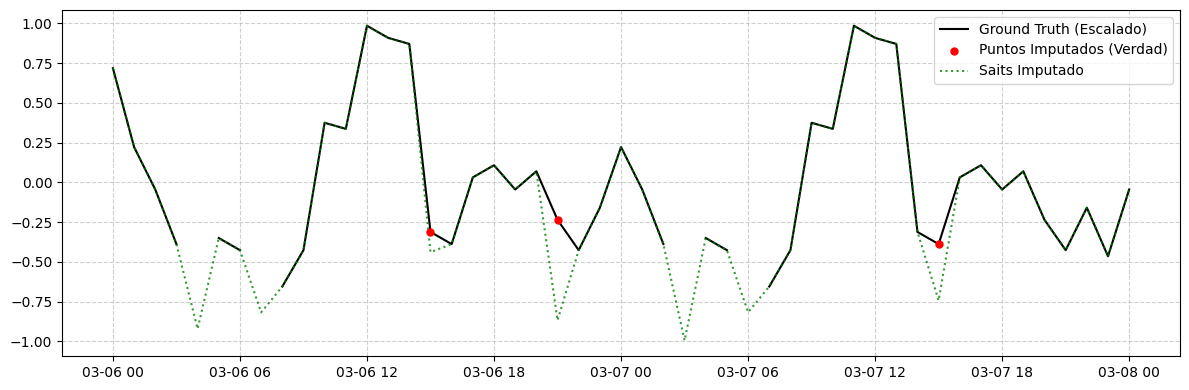

In [35]:
import matplotlib.pyplot as plt
import pandas as pd
# Asumiendo que 'config', 'periodo_1_raw', 'processed_data', 'imputed_results', 'utils'
# y 'dataset_for_testing' están definidos en el contexto de tu script.

# --- Configuración y Carga de Datos (asumiendo que ya están definidos) ---
# feature_to_plot = "NO2"
# config.FEATURE_COLUMNS = [...] # Lista de nombres de columnas de características
# periodo_1_raw = pd.DataFrame(...) # DataFrame original con datos crudos
# processed_data = {'scaler': scaler_object, 'test_index': test_index_full, 'n_features': n_features}
# imputed_results = {'saits': saits_imputed_array, ...} # Diccionario con resultados de imputación
# utils.reshape_imputed_to_df = function(...) # Función utilitaria
# dataset_for_testing = {'X_ori': original_scaled_test_windows, 'indicating_mask': mask_array} # Datos originales ANTES de enmascarar y la máscara


# Seleccionar una característica para visualizar
feature_to_plot = "NO2"
if feature_to_plot not in config.FEATURE_COLUMNS:
    print(f"Advertencia: '{feature_to_plot}' no está en las columnas de características. Saltando gráfico.")
else:
    feature_index = config.FEATURE_COLUMNS.index(feature_to_plot)

    # Obtener datos originales de test (antes de ventanear) para el rango deseado
    # Usamos el mismo rango que en el zoom del gráfico anterior para detalle
    plot_start = "2023-03-06 00:00:00"
    plot_end = "2023-03-08 00:00:00"
    test_index_full = periodo_1_raw.index
    test_df_original = periodo_1_raw.loc[plot_start:plot_end]

    # --- 2. Graficar Ground Truth (donde se introdujo la ausencia) - escalado ---
    # Reconstruir la serie temporal ground truth desde test_X_ori (datos originales escalados antes de enmascarar)
    ground_truth_df = utils.reshape_imputed_to_df(
         dataset_for_testing['X_ori'], # Usar los datos escalados originales completos
         test_index_full, # Usar el índice completo antes de ventanear
         config.FEATURE_COLUMNS,
         config.N_STEPS
         )

    # Extraer el rango de tiempo relevante para graficar desde el Ground Truth
    # Asegurarse que los índices coincidan con el rango deseado
    if plot_start in ground_truth_df.index and plot_end in ground_truth_df.index:
        ground_truth_series = ground_truth_df.loc[plot_start:plot_end, feature_to_plot]

        # Marcar los puntos que eran originalmente faltantes (usando la máscara)
        # Necesitamos aplanar la máscara para que coincida con la serie temporal
        mask_flat = dataset_for_testing['indicating_mask'].reshape(-1, processed_data['n_features'])
        # Crear índice para la máscara aplanada que coincida con ground_truth_df
        # Asegurarse que la longitud del índice coincida con la máscara aplanada
        mask_index = ground_truth_df.index[:len(mask_flat)]
        mask_series = pd.Series(mask_flat[:, feature_index], index=mask_index).loc[plot_start:plot_end] # Filtrar por el rango de graficado

        # Obtener los índices de los puntos que faltaban (donde la máscara es 1)
        missing_indices = mask_series[mask_series == 1].index

        # Graficar la línea Ground Truth
        plt.plot(ground_truth_series.index, ground_truth_series.values,
                 label='Ground Truth (Escalado)',
                 color='black',
                 linewidth=1.5)

        # Graficar los puntos rojos de los Ground Truth que faltaban
        # Asegurar que los missing_indices existan en ground_truth_series antes de graficar
        valid_missing_indices = missing_indices.intersection(ground_truth_series.index)
        plt.scatter(valid_missing_indices, ground_truth_series.loc[valid_missing_indices],
                    color='red',
                    s=25, # Tamaño un poco más grande para que se vean mejor
                    label='Puntos Imputados (Verdad)', # Etiqueta clara para los puntos
                    zorder=5) # Asegurar que los puntos se dibujen encima de las líneas

    else:
        print("Advertencia: Rango de fechas de test original no encontrado completamente en datos ground truth reconstruidos. Saltando gráfico de ground truth.")
        ground_truth_series = None # Para evitar errores posteriores

    # --- 3. Graficar resultados imputados para 'Saits' ---
    method_to_plot = 'saits' # Elegir el método Saits
    imputed_color = 'green' # Elegir un color
    imputed_linestyle = ':' # Usar el estilo punteado

    if method_to_plot in imputed_results:
        y_pred_saits = imputed_results[method_to_plot]

        # Reestructurar la predicción de Saits
        imputed_df_saits = utils.reshape_imputed_to_df(
             y_pred_saits,
             test_index_full, # Usar índice completo de test
             config.FEATURE_COLUMNS,
             config.N_STEPS
        )

        # Extraer la serie de Saits para la característica y el rango de tiempo deseado
        if plot_start in imputed_df_saits.index and plot_end in imputed_df_saits.index:
            imputed_series_saits = imputed_df_saits.loc[plot_start:plot_end, feature_to_plot]

            plt.plot(imputed_series_saits.index, imputed_series_saits.values,
                     label=f'{method_to_plot.title()} Imputado',
                     color=imputed_color,
                     linestyle=imputed_linestyle,
                     alpha=0.8)
        else:
             print(f"Advertencia: Rango de fechas de test original no encontrado completamente en datos imputados ({method_to_plot}). Saltando gráfico parcial.")

    else:
        print(f"Advertencia: El método '{method_to_plot}' no se encuentra en los resultados imputados.")


    # --- Elementos Adicionales del Gráfico ---
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

## 9. Opcional: Guardar Resultados

Podemos guardar la tabla de evaluación y/o los datos imputados (por ejemplo, los resultados de SAITS) en archivos CSV si es necesario para análisis posteriores o informes.

In [36]:
# Guardar la tabla de evaluación
# evaluation_table.to_csv(f"{config.RESULTS_DIR}/imputation_evaluation.csv")
# print(f"Resultados de evaluación guardados en {config.RESULTS_DIR}/imputation_evaluation.csv")

# Guardar datos imputados (ej. resultado de SAITS) si es necesario
# saits_imputed_df = utils.reshape_imputed_to_df(...) # Necesitas reconstruir el DataFrame
# saits_imputed_df.to_csv(...)

print("\nFlujo de trabajo finalizado.")


Flujo de trabajo finalizado.
